In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Step 1 — Load & Explore Data

In [2]:
df = pd.read_csv('cleaned_patient_with_hospital.csv')
df.head()

,disease_type,sex,marital_status,nationality,occupation,district,date_disease_start,patient_status,patient_type,hospital_name,age
0,dengue,male,single,thai,employed,bang_khun_thian,1/1/2026,in_care,inpatient,โรงพยาบาลบางปะกอก 8 โรงพยาบาลทั่วไปขนาดใหญ่,39.755479
1,dengue,male,single,thai,unknown,din_daeng,1/1/2026,in_care,inpatient,โรงพยาบาลลาดพร้าว,10.166667
2,dengue,male,single,thai,unknown,phra_khanong,1/1/2026,in_care,inpatient,โรงพยาบาลหัวเฉียวโรงพยาบาลทั่วไปขนาดใหญ่,6.240639
3,dengue,male,single,thai,unknown,khlong_san,1/1/2026,unknown,outpatient,โรงพยาบาลหัวเฉียวโรงพยาบาลทั่วไปขนาดใหญ่,42.073973
4,dengue,male,single,thai,unknown,thawi_watthana,1/1/2026,unknown,outpatient,โรงพยาบาลราชพิพัฒน์,8.699543


In [3]:
# FIX: specify the column to count — df.value_counts() on the whole DataFrame
# is very slow and rarely meaningful.
df['disease_type'].value_counts()

disease_type
diarrhea     34252
influenza    18393
pneumonia     5912
dengue         698
covid19        646
Name: count, dtype: int64

In [4]:
df.isna().sum()

disease_type          0
sex                   0
marital_status        0
nationality           0
occupation            0
district              0
date_disease_start    0
patient_status        0
patient_type          0
hospital_name         0
age                   0
dtype: int64

## Step 2 — Encode & Scale

**Fix:** Store each OrdinalEncoder so labels can be decoded later and new data
can be transformed consistently.  
**Fix:** Save the fitted scaler with joblib so inference is reproducible.

In [5]:
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
import pandas as pd
import joblib

# Separate target
y_true = df['disease_type'].copy()
x = df.drop(columns='disease_type')

# Apply OrdinalEncoder to all categorical columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x_encoded = pd.DataFrame(
    encoder.fit_transform(x),
    columns=x.columns
)

# Scale features
scaler = MinMaxScaler()
x_scaled = pd.DataFrame(
    scaler.fit_transform(x_encoded),
    columns=x.columns
)

# Save encoder and scaler
joblib.dump(encoder, 'ordinal_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Ordinal encoder and scaler saved.")

Ordinal encoder and scaler saved.


## Step 3 — Find Optimal k (Elbow + Silhouette)

**Fix:** Run the search loop once and derive `optimal_k` programmatically from
the silhouette scores so downstream models use the *same* recommended value
without manual edits.

In [6]:
Sum_of_squared_distances = []
Silhouette = []

K = range(2, 15)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    labels = km.labels_
    Sum_of_squared_distances.append(km.inertia_)
    if len(set(labels)) > 1:
        Silhouette.append(silhouette_score(x_scaled, labels))
    else:
        Silhouette.append(-1)

# FIX: derive optimal_k programmatically instead of hard-coding
optimal_k = list(K)[np.argmax(Silhouette)]
print(f"Optimal k based on silhouette: {optimal_k}")

Optimal k based on silhouette: 4


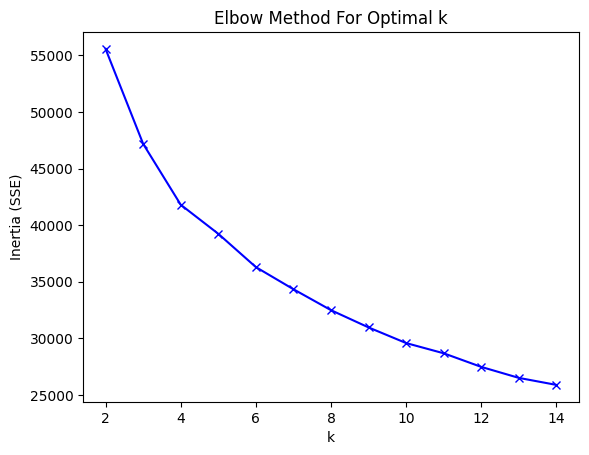

In [7]:
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method For Optimal k')
plt.show()

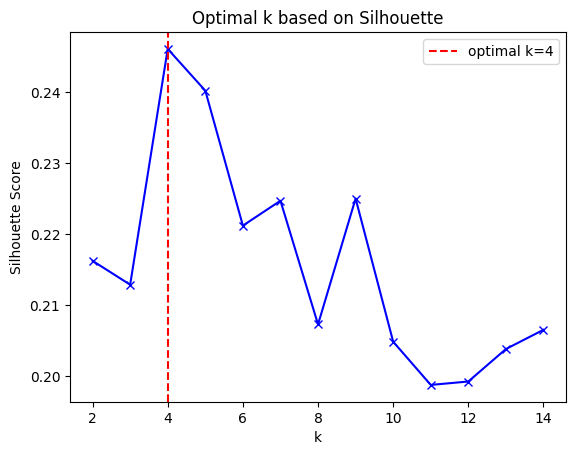

In [8]:
plt.plot(K, Silhouette, 'bx-')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'optimal k={optimal_k}')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Optimal k based on Silhouette')
plt.legend()
plt.show()

## Step 4 — Fit Final KMeans Model

**Fix:** Use `optimal_k` (derived above) instead of a hard-coded value.  
**Fix:** Add `random_state` and `n_init` for reproducibility.  
**Fix:** Use consistent 0-based cluster index names.

In [9]:
# FIX: use optimal_k, add random_state & n_init for reproducibility
km_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
km_final.fit(x_scaled)
cluster_labels = km_final.labels_

# FIX: consistent 0-based index names
index_names = [f'cluster_{i}' for i in range(optimal_k)]
cluster_result = pd.DataFrame(
    km_final.cluster_centers_,
    columns=x_scaled.columns,
    index=index_names
)
cluster_result

,sex,marital_status,nationality,occupation,district,date_disease_start,patient_status,patient_type,hospital_name,age
cluster_0,4.773959e-15,0.709419,0.628421,0.841301,0.482223,0.493088,0.986291,0.888930,0.583666,0.466656
cluster_1,1.000000e+00,0.597600,0.501293,0.687338,0.463065,0.487949,0.033723,0.742112,0.599814,0.417295
cluster_2,-6.883383e-15,0.578133,0.509258,0.694237,0.452221,0.493697,0.030452,0.797747,0.613778,0.484176
cluster_3,1.000000e+00,0.747789,0.633492,0.823487,0.495365,0.489832,0.987633,0.882098,0.576324,0.409009


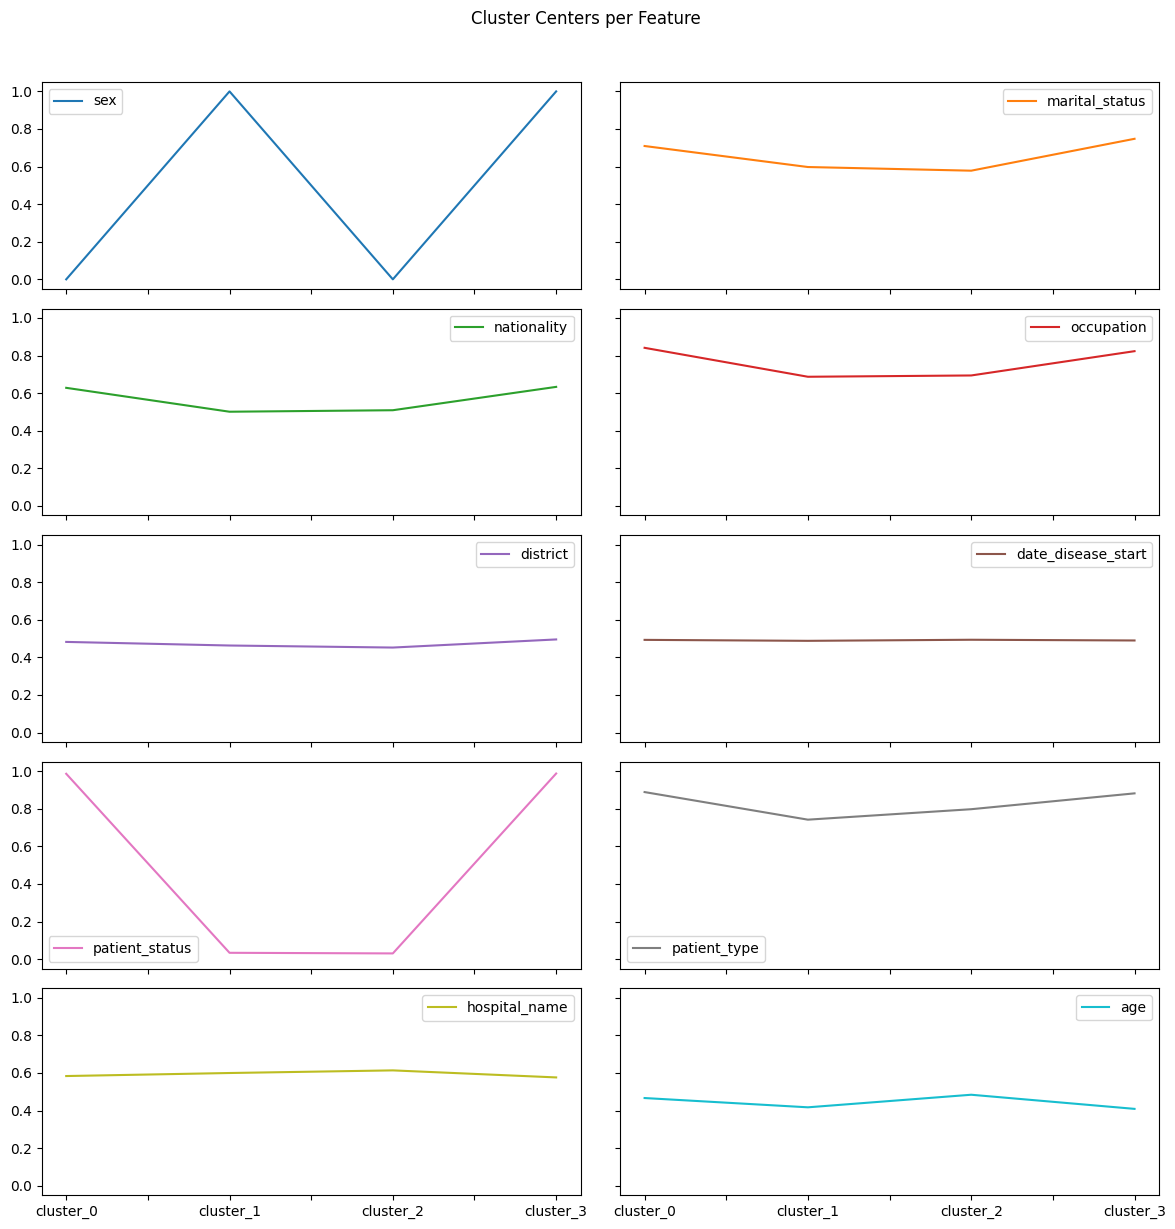

In [10]:
cluster_result.plot(subplots=True, layout=(-1, 2), sharey=True, figsize=(12, 12))
plt.suptitle('Cluster Centers per Feature', y=1.02)
plt.tight_layout()
plt.show()

## Step 5 — Evaluate Clusters Against `disease_type`

**Fix:** Cross-tabulate cluster assignments against the original `disease_type`
label and compute information-theoretic alignment scores.
This answers whether the unsupervised clusters "found" the disease groups.

In [11]:
# # Encode disease_type numerically for scoring
# le_disease = LabelEncoder()
# y_encoded = le_disease.fit_transform(y_true)

# nmi = normalized_mutual_info_score(y_encoded, cluster_labels)
# ari = adjusted_rand_score(y_encoded, cluster_labels)
# sil = silhouette_score(x_scaled, cluster_labels)

# print(f"Silhouette Score      : {sil:.4f}  (higher is better, max=1)")
# print(f"Normalized Mutual Info: {nmi:.4f}  (higher = more overlap with disease_type)")
# print(f"Adjusted Rand Index   : {ari:.4f}  (1=perfect match, 0=random)")

# # Cross-tabulation
# df_eval = df[['disease_type']].copy()
# df_eval['cluster'] = cluster_labels
# cross_tab = pd.crosstab(df_eval['cluster'], df_eval['disease_type'])
# print("\nCross-tabulation of clusters vs disease_type:")
# cross_tab
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
import numpy as np
import pandas as pd

# Encode disease_type using OrdinalEncoder (expects 2D)
encoder_disease = OrdinalEncoder()
y_encoded = encoder_disease.fit_transform(y_true.values.reshape(-1, 1)).ravel()

# Metrics
nmi = normalized_mutual_info_score(y_encoded, cluster_labels)
ari = adjusted_rand_score(y_encoded, cluster_labels)

# Silhouette safety check
if len(set(cluster_labels)) > 1:
    sil = silhouette_score(x_scaled, cluster_labels)
else:
    sil = -1  # or np.nan

print(f"Silhouette Score      : {sil:.4f}  (higher is better, max=1)")
print(f"Normalized Mutual Info: {nmi:.4f}  (higher = more overlap with disease_type)")
print(f"Adjusted Rand Index   : {ari:.4f}  (1=perfect match, 0=random)")

# Cross-tabulation
df_eval = df[['disease_type']].copy()
df_eval['cluster'] = cluster_labels

cross_tab = pd.crosstab(df_eval['cluster'], df_eval['disease_type'])
print("\nCross-tabulation of clusters vs disease_type:")
print(cross_tab)

# Normalized cross-tab (cluster purity)
cross_tab_norm = cross_tab.div(cross_tab.sum(axis=1), axis=0)
print("\nNormalized Cross-tab (cluster purity):")
print(cross_tab_norm)

# Dominant disease per cluster
dominant = cross_tab.idxmax(axis=1)
print("\nDominant disease per cluster:")
print(dominant)

Silhouette Score      : 0.2460  (higher is better, max=1)
Normalized Mutual Info: 0.0128  (higher = more overlap with disease_type)
Adjusted Rand Index   : 0.0258  (1=perfect match, 0=random)

Cross-tabulation of clusters vs disease_type:
disease_type  covid19  dengue  diarrhea  influenza  pneumonia
cluster                                                      
0                 277     104     13816       5591       1622
1                  73     240      4271       3730       1353
2                 136     225      6335       4715       1281
3                 160     129      9830       4357       1656

Normalized Cross-tab (cluster purity):
disease_type   covid19    dengue  diarrhea  influenza  pneumonia
cluster                                                         
0             0.012938  0.004858  0.645306   0.261140   0.075759
1             0.007551  0.024827  0.441812   0.385849   0.139961
2             0.010715  0.017728  0.499133   0.371494   0.100930
3             0.009918  

## Step 6 — Visualise Clusters (PCA 2-D)

A 2-D PCA projection lets us visually inspect cluster separation.

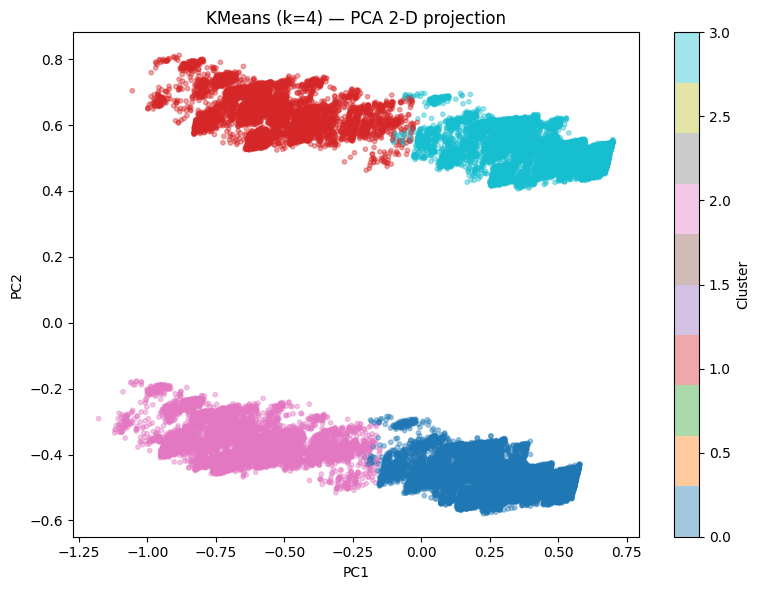

In [12]:
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.4, s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'KMeans (k={optimal_k}) — PCA 2-D projection')
plt.tight_layout()
plt.show()